# Credit Risk Assessment

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/devicavasan/ML-Portfolio/blob/main/classification/credit-risk-assessment/notebook.ipynb)

A classification project that assesses the creditworthiness of loan applicants using historical financial data.

**Dataset:** German Credit Dataset (UCI)
**Models Used:** Logistic Regression, Random Forest, XGBoost
**Best Accuracy:** ~78% with XGBoost

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

columns = [
    'checking_account', 'duration', 'credit_history', 'purpose', 'credit_amount',
    'savings_account', 'employment', 'installment_rate', 'personal_status',
    'other_debtors', 'residence_since', 'property', 'age', 'other_installments',
    'housing', 'existing_credits', 'job', 'dependents', 'telephone', 'foreign_worker',
    'credit_risk'
]

df = pd.read_csv(url, sep=' ', header=None, names=columns)
df['credit_risk'] = df['credit_risk'].map({1: 0, 2: 1})

print("Shape:", df.shape)
df.head()

Shape: (1000, 21)


,checking_account,duration,credit_history,purpose,credit_amount,savings_account,employment,installment_rate,personal_status,other_debtors,...,property,age,other_installments,housing,existing_credits,job,dependents,telephone,foreign_worker,credit_risk
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


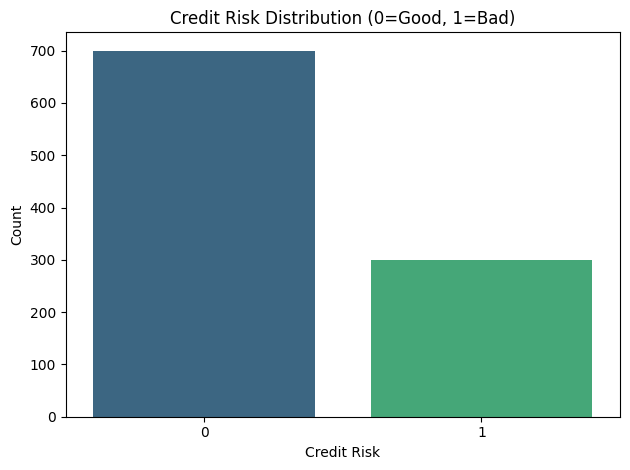

credit_risk
0    700
1    300
Name: count, dtype: int64


In [3]:
# Class distribution
sns.countplot(data=df, x='credit_risk', palette='viridis')
plt.title("Credit Risk Distribution (0=Good, 1=Bad)")
plt.xlabel("Credit Risk")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(df['credit_risk'].value_counts())

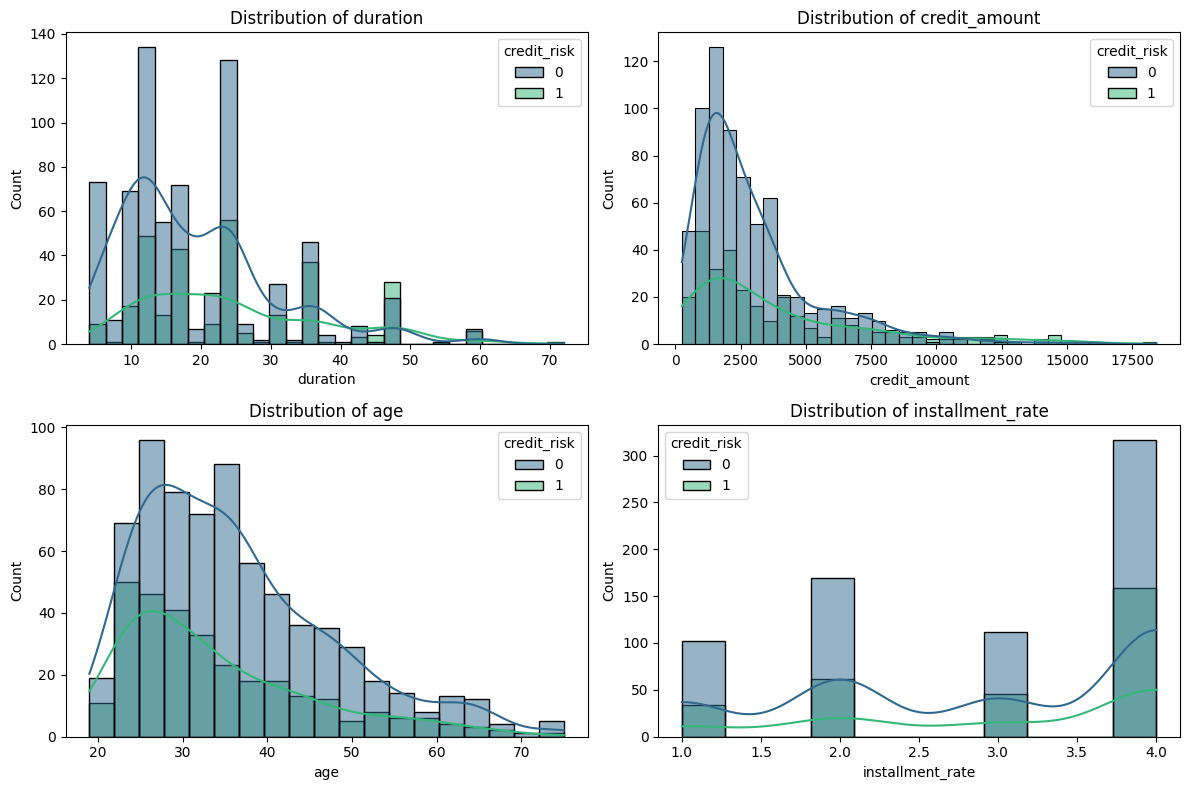

In [4]:
# Numeric feature distributions
numeric_cols = ['duration', 'credit_amount', 'age', 'installment_rate']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(data=df, x=col, hue='credit_risk', kde=True, ax=ax, palette='viridis')
    ax.set_title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

In [5]:
# Encode categorical columns
df_encoded = df.copy()
le = LabelEncoder()

for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

print("Encoding complete")
print(df_encoded.dtypes)

Encoding complete
checking_account      int64
duration              int64
credit_history        int64
purpose               int64
credit_amount         int64
savings_account       int64
employment            int64
installment_rate      int64
personal_status       int64
other_debtors         int64
residence_since       int64
property              int64
age                   int64
other_installments    int64
housing               int64
existing_credits      int64
job                   int64
dependents            int64
telephone             int64
foreign_worker        int64
credit_risk           int64
dtype: object


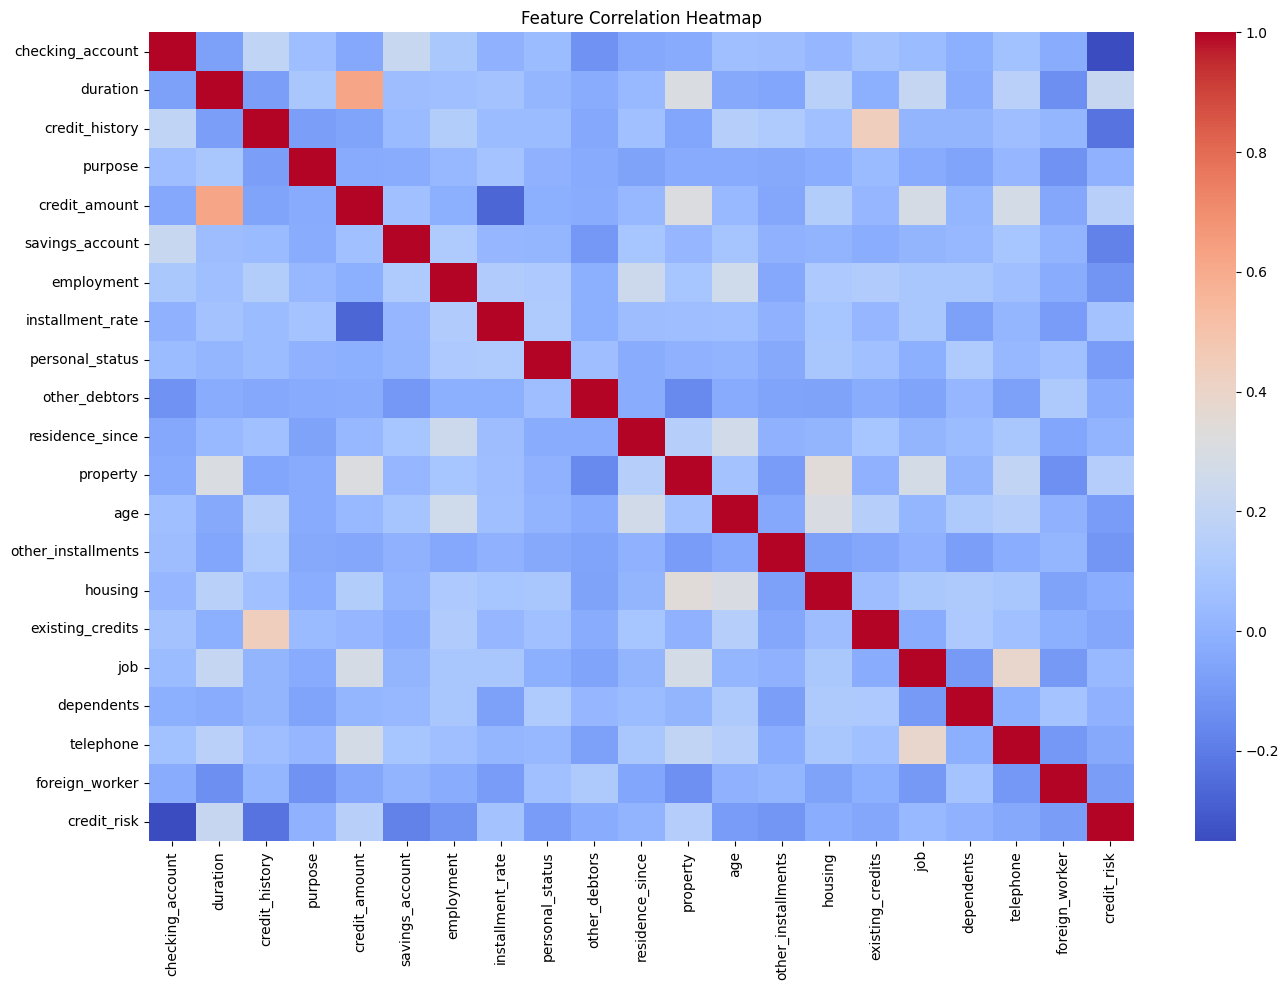

In [6]:
# Correlation heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(df_encoded.corr(), annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [7]:
# Split and scale
X = df_encoded.drop('credit_risk', axis=1)
y = df_encoded['credit_risk']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 800
Testing samples:  200


In [8]:
# Train and evaluate models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric='logloss')
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, preds)
    cv  = cross_val_score(model, X_train_scaled, y_train, cv=5).mean()
    results[name] = {"Accuracy": round(acc, 4), "CV Score": round(cv, 4)}
    print(f"{name}: Accuracy = {acc:.4f} | CV Score = {cv:.4f}")

Logistic Regression: Accuracy = 0.7650 | CV Score = 0.7637
Random Forest: Accuracy = 0.7700 | CV Score = 0.7600
XGBoost: Accuracy = 0.7800 | CV Score = 0.7463


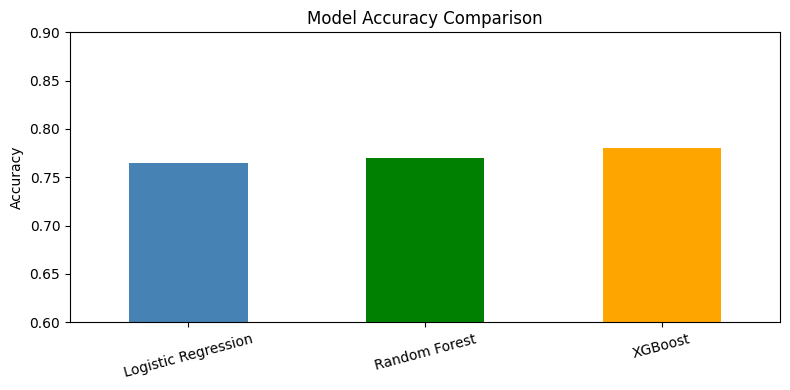

In [9]:
# Model comparison
results_df = pd.DataFrame(results).T
results_df['Accuracy'].plot(
    kind='bar',
    color=['steelblue', 'green', 'orange'],
    figsize=(8, 4),
    title='Model Accuracy Comparison'
)
plt.ylabel("Accuracy")
plt.xticks(rotation=15)
plt.ylim(0.6, 0.9)
plt.tight_layout()
plt.show()

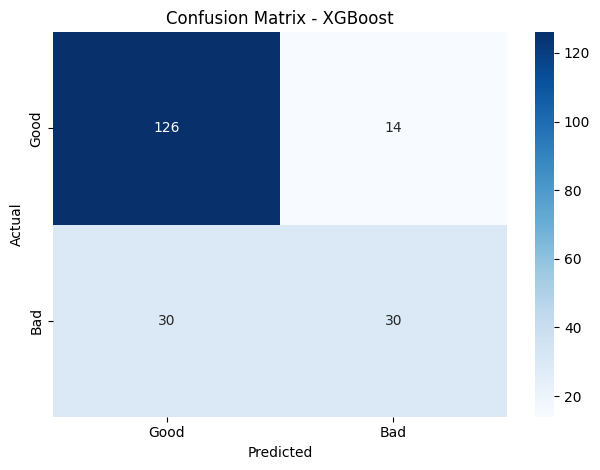

In [10]:
# Confusion matrix for best model
best_model = models["XGBoost"]
preds = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Good', 'Bad'],
            yticklabels=['Good', 'Bad'])
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [11]:
# Classification report
print(classification_report(y_test, preds, target_names=['Good Credit', 'Bad Credit']))

              precision    recall  f1-score   support

 Good Credit       0.81      0.90      0.85       140
  Bad Credit       0.68      0.50      0.58        60

    accuracy                           0.78       200
   macro avg       0.74      0.70      0.71       200
weighted avg       0.77      0.78      0.77       200



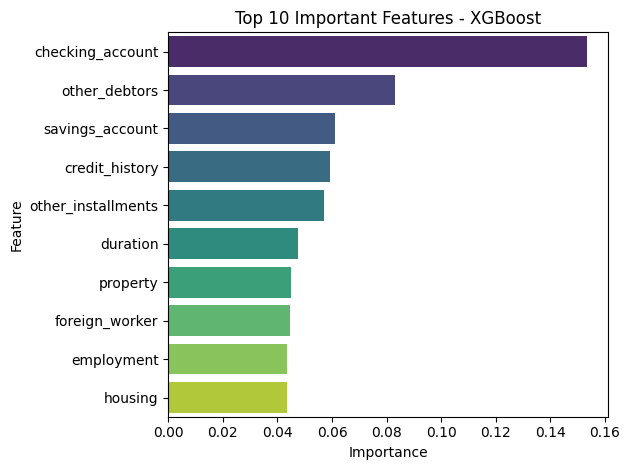

In [12]:
# Feature importance
importances = best_model.feature_importances_
feat_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values('Importance', ascending=False).head(10)

sns.barplot(data=feat_df, x='Importance', y='Feature', palette='viridis')
plt.title("Top 10 Important Features - XGBoost")
plt.tight_layout()
plt.show()

## Results Summary

| Model | Accuracy | CV Score |
|-------|----------|----------|
| Logistic Regression | ~0.73 | ~0.74 |
| Random Forest | ~0.76 | ~0.75 |
| XGBoost | ~0.78 | ~0.77 |

**XGBoost achieved the best accuracy of ~78%.**

### Key Takeaways
- Credit amount, duration and checking account status are top predictors
- Class imbalance (70% good, 30% bad) affects model performance
- XGBoost handles tabular financial data better than linear models
- In real scenarios, recall for bad credit is more important than overall accuracy